# Module 2: Named Entity Recognition (NER)
### Fine-Tuning BERT on CoNLL-2003

## Install Packages

In [1]:
!pip install datasets==2.18.0 transformers accelerate sentencepiece
!pip install evaluate seqeval
!pip install pandas matplotlib seaborn tqdm
!pip install numpy==1.26.4

## Import Libraries

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import torch
import evaluate
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    pipeline,
    set_seed,
)

warnings.filterwarnings("ignore")
set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

BASE_DIR = Path("./nlu_models")
BASE_DIR.mkdir(exist_ok=True)

NER_DIR = BASE_DIR / "ner_model"
NER_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
print(f"Model will be saved in: {NER_DIR.absolute()}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Model will be saved in: /content/nlu_models/ner_model


## 2.1 Load & Explore CoNLL-2003

In [3]:
ds_ner_raw = load_dataset("eriktks/conll2003", trust_remote_code=True)
print(ds_ner_raw)
print("\nFeatures:", ds_ner_raw["train"].features)

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Features: {'id': Value(dtype='string', id=None), 'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'pos_tags': Sequence(feature=ClassLabel(names=['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB'], id=None), length=-1, id=None), 'chunk_tags': Sequence(feature=ClassLabel(names=['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 

In [4]:
ner_label_list = ds_ner_raw["train"].features["ner_tags"].feature.names
print(f"NER Labels ({len(ner_label_list)}): {ner_label_list}")

df_ner_sample = pd.DataFrame(ds_ner_raw["train"].select(range(5)))
display(df_ner_sample[["tokens", "ner_tags"]].head(3))

NER Labels (9): ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


,tokens,ner_tags
0,"[EU, rejects, German, call, to, boycott, Briti...","[3, 0, 7, 0, 0, 0, 7, 0, 0]"
1,"[Peter, Blackburn]","[1, 2]"
2,"[BRUSSELS, 1996-08-22]","[5, 0]"


## 2.2 EDA

In [5]:
df_ner_train = pd.DataFrame(ds_ner_raw["train"])
df_ner_train["n_tokens"] = df_ner_train["tokens"].apply(len)

all_tags = [tag for tags in df_ner_train["ner_tags"] for tag in tags]
tag_counts = Counter(all_tags)

print(f"Train sentences: {len(df_ner_train):,}")
print(f"Avg tokens/sentence: {df_ner_train['n_tokens'].mean():.1f}")
print(f"Total tokens: {df_ner_train['n_tokens'].sum():,}")

Train sentences: 14,041
Avg tokens/sentence: 14.5
Total tokens: 203,621


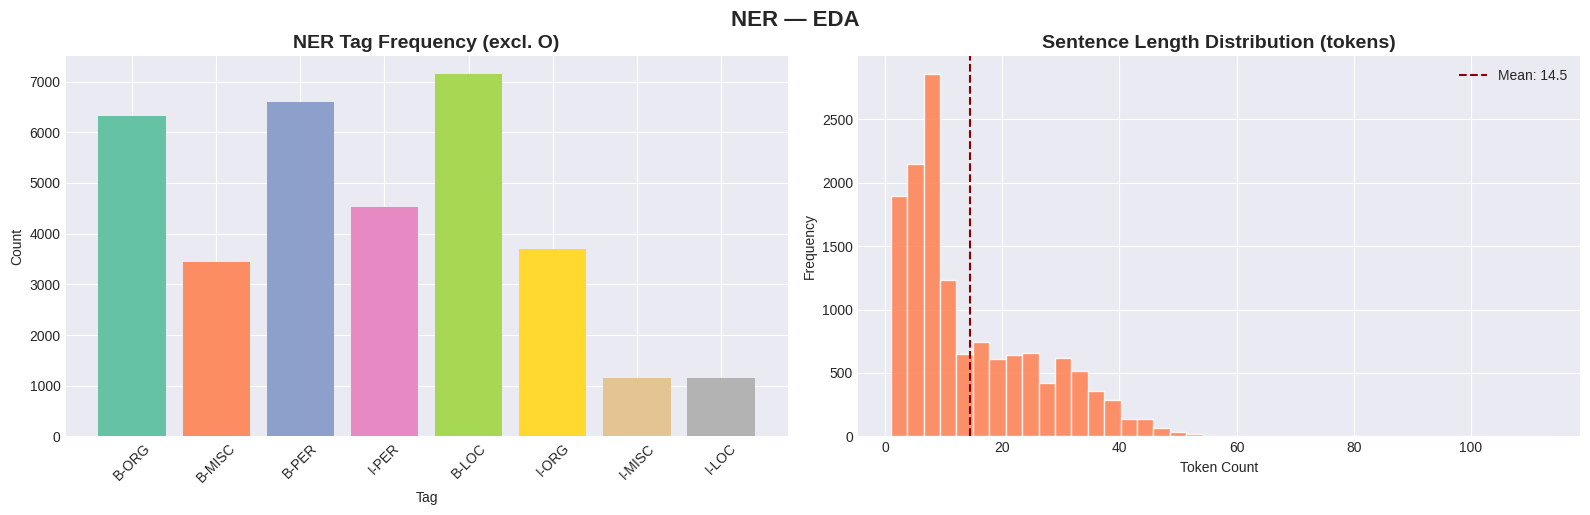

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

non_o_tags = {ner_label_list[k]: v for k, v in tag_counts.items() if ner_label_list[k] != "O"}
axes[0].bar(non_o_tags.keys(), non_o_tags.values(),
            color=sns.color_palette("Set2", len(non_o_tags)))
axes[0].set_title("NER Tag Frequency (excl. O)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Tag")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(df_ner_train["n_tokens"], bins=40, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvline(df_ner_train["n_tokens"].mean(), color="darkred", linestyle="--",
                label=f"Mean: {df_ner_train['n_tokens'].mean():.1f}")
axes[1].set_title("Sentence Length Distribution (tokens)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Token Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.suptitle("NER — EDA", fontsize=16, fontweight="bold", y=1.02)
plt.savefig(BASE_DIR / "ner_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.3 Data Cleaning

In [7]:
def clean_ner_split(dataset_split, max_len=128):
    df = pd.DataFrame(dataset_split)
    orig = len(df)
    df = df[df["tokens"].apply(len) > 0].reset_index(drop=True)
    df = df[df["tokens"].apply(len) <= max_len].reset_index(drop=True)
    df = df[df.apply(lambda r: len(r["tokens"]) == len(r["ner_tags"]), axis=1)].reset_index(drop=True)
    print(f"  {orig} -> {len(df)} sequences (removed {orig - len(df)})")
    return Dataset.from_pandas(df[["tokens", "ner_tags", "pos_tags", "chunk_tags"]])

ds_ner_clean = DatasetDict({
    "train":      clean_ner_split(ds_ner_raw["train"]),
    "validation": clean_ner_split(ds_ner_raw["validation"]),
    "test":       clean_ner_split(ds_ner_raw["test"]),
})

  14041 -> 14041 sequences (removed 0)
  3250 -> 3250 sequences (removed 0)
  3453 -> 3453 sequences (removed 0)


## 2.4 Tokenization + Label Alignment

In [8]:
NER_MODEL_NAME = "bert-base-cased"
print(f"Loading tokenizer: {NER_MODEL_NAME}")

ner_tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_NAME)
MAX_LEN_NER = 128

def tokenize_and_align_labels(examples):
    tokenized_inputs = ner_tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=MAX_LEN_NER,
        is_split_into_words=True,
    )
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(label[word_id])
            else:
                label_ids.append(-100)
            prev_word_id = word_id
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

ds_ner_tok = ds_ner_clean.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=ds_ner_clean["train"].column_names,
    desc="Aligning NER labels"
)
ds_ner_tok.set_format("torch")
print(ds_ner_tok)

Loading tokenizer: bert-base-cased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Aligning NER labels:   0%|          | 0/14041 [00:00<?, ? examples/s]

Aligning NER labels:   0%|          | 0/3250 [00:00<?, ? examples/s]

Aligning NER labels:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})


## 2.5 Fine-Tuning BERT for NER

In [9]:
id2label_ner = {i: l for i, l in enumerate(ner_label_list)}
label2id_ner = {l: i for i, l in enumerate(ner_label_list)}

ner_model = AutoModelForTokenClassification.from_pretrained(
    NER_MODEL_NAME,
    num_labels=len(ner_label_list),
    id2label=id2label_ner,
    label2id=label2id_ner,
    ignore_mismatched_sizes=True,
)
ner_model.to(DEVICE)

total_ner = sum(p.numel() for p in ner_model.parameters())
print(f"Model: {NER_MODEL_NAME}")
print(f"  Total params: {total_ner:,}")
print(f"  NER labels:   {len(ner_label_list)}")

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Model: bert-base-cased
  Total params: 107,726,601
  NER labels:   9


In [10]:
seqeval_metric = evaluate.load("seqeval")

def compute_ner_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_preds = [
        [ner_label_list[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(preds, labels)
    ]
    true_labels = [
        [ner_label_list[l] for l in label if l != -100]
        for label in labels
    ]

    results = seqeval_metric.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

In [11]:
num_training_steps = (len(ds_ner_tok["train"]) // 32) * 5
warmup_steps = int(0.1 * num_training_steps)

ner_training_args = TrainingArguments(
    output_dir=str(NER_DIR),
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
)

In [12]:
ner_trainer = Trainer(
    model=ner_model,
    args=ner_training_args,
    train_dataset=ds_ner_tok["train"],
    eval_dataset=ds_ner_tok["validation"],
    data_collator=DataCollatorForTokenClassification(ner_tokenizer),
    compute_metrics=compute_ner_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Model:  {NER_MODEL_NAME}")
print(f"Train:  {len(ds_ner_tok['train']):,} samples")
print(f"Val:    {len(ds_ner_tok['validation']):,} samples")

ner_train_result = ner_trainer.train()

print(f"Loss:    {ner_train_result.training_loss:.4f}")
print(f"Runtime: {ner_train_result.metrics['train_runtime']:.0f}s")

Model:  bert-base-cased
Train:  14,041 samples
Val:    3,250 samples


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.053826,0.046476,0.921141,0.924865,0.922999,0.987121
2,0.029056,0.040692,0.937134,0.944239,0.940673,0.989810
3,0.012542,0.036567,0.943469,0.950303,0.946874,0.990979
4,0.008251,0.037660,0.945549,0.953673,0.949593,0.991271
5,0.005199,0.037890,0.947175,0.954515,0.950831,0.991427


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Loss:    0.0775
Runtime: 368s


## 2.6 Testing & Evaluation — NER

In [13]:
print("Evaluating NER on TEST set...")
ner_test_results = ner_trainer.evaluate(ds_ner_tok["test"])

print("\nNER Test Results:")
for k, v in ner_test_results.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

Evaluating NER on TEST set...



NER Test Results:
  eval_loss: 0.1127
  eval_precision: 0.9045
  eval_recall: 0.9196
  eval_f1: 0.9120
  eval_accuracy: 0.9823
  eval_runtime: 4.5670
  eval_samples_per_second: 756.0720
  eval_steps_per_second: 11.8240
  epoch: 5.0000


In [14]:
ner_preds_out = ner_trainer.predict(ds_ner_tok["test"])
y_pred_ner = np.argmax(ner_preds_out.predictions, axis=-1)
y_true_ner = ner_preds_out.label_ids

true_preds_full = [
    [ner_label_list[p] for p, l in zip(pred, label) if l != -100]
    for pred, label in zip(y_pred_ner, y_true_ner)
]
true_labels_full = [
    [ner_label_list[l] for l in label if l != -100]
    for label in y_true_ner
]

detailed = seqeval_metric.compute(predictions=true_preds_full, references=true_labels_full)
print("\nPer-Entity Results:")
for entity_type in ["PER", "ORG", "LOC", "MISC"]:
    if entity_type in detailed:
        ed = detailed[entity_type]
        print(f"  {entity_type}: P={ed['precision']:.3f}  R={ed['recall']:.3f}  F1={ed['f1']:.3f}  Support={ed['number']}")


Per-Entity Results:
  PER: P=0.969  R=0.957  F1=0.963  Support=1615
  ORG: P=0.874  R=0.915  F1=0.894  Support=1661
  LOC: P=0.931  R=0.932  F1=0.932  Support=1666
  MISC: P=0.778  R=0.815  F1=0.796  Support=702


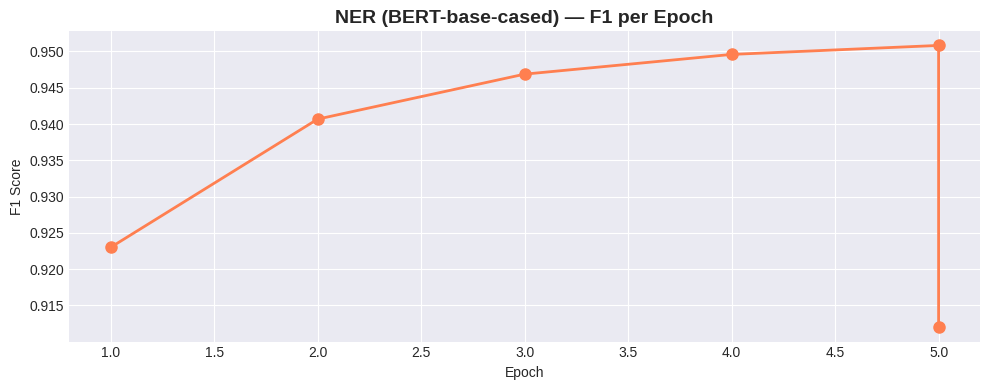

In [15]:
ner_history = [
    (e["epoch"], e["eval_f1"])
    for e in ner_trainer.state.log_history
    if "eval_f1" in e
]

if ner_history:
    ep, f1 = zip(*ner_history)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ep, f1, "o-", color="coral", linewidth=2, markersize=8)
    ax.set_title("NER (BERT-base-cased) — F1 per Epoch", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1 Score")
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(BASE_DIR / "ner_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()

In [16]:
ner_pipe = pipeline(
    "ner", model=ner_model, tokenizer=ner_tokenizer,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

meeting_texts = [
    "John Smith will present the Q3 report to Microsoft's board in New York on Friday.",
    "Sarah from Google mentioned that the AWS deployment in Frankfurt is complete.",
    "The budget approval from CFO James Lee is required before the IBM partnership proceeds.",
]

for text in meeting_texts:
    entities = ner_pipe(text)
    print(f"Text: '{text}'")
    for ent in entities:
        print(f"  [{ent['entity_group']}] '{ent['word']}' (score: {ent['score']:.3f})")
    print()

Text: 'John Smith will present the Q3 report to Microsoft's board in New York on Friday.'
  [PER] 'John Smith' (score: 0.999)
  [ORG] 'Microsoft' (score: 0.999)
  [LOC] 'New York' (score: 1.000)

Text: 'Sarah from Google mentioned that the AWS deployment in Frankfurt is complete.'
  [PER] 'Sarah' (score: 0.993)
  [ORG] 'Google' (score: 0.994)
  [MISC] 'AWS' (score: 0.883)
  [LOC] 'Frankfurt' (score: 0.999)

Text: 'The budget approval from CFO James Lee is required before the IBM partnership proceeds.'
  [ORG] 'CF' (score: 0.608)
  [PER] 'James Lee' (score: 0.999)
  [ORG] 'IBM' (score: 0.999)



## 2.7 Save NER Model

In [17]:
ner_trainer.save_model(str(NER_DIR))
ner_tokenizer.save_pretrained(str(NER_DIR))
print(f"NER model saved to: {NER_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

NER model saved to: nlu_models/ner_model
